In [36]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#task1
#subtask 1.1 dataset loading and inspection
df = pd.read_csv("/content/download.csv") #upload the data
df.head() #look on the first 5 rows to see the columns names and records


,learner_id,gender,age,education_level,course_type,learning_mode,region,device_type,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score,participation_level,completion_status,performance_category
0,LRN00001,Male,30.0,Undergraduate,Business,Blended,Upper Egypt,Mobile,7.2,26 videos,4,73.4,75.1,69.1,64.706031,High,Completed,Good
1,LRN00002,Male,34.0,Graduate,Business,Self-paced,Delta,Laptop,9.3,22 videos,5,69.8,85.8,76.3,69.859459,High,Completed,Very Good
2,LRN00003,Female,22.0,Graduate,Business,Blended,Cairo,Mobile,8.6,27 videos,2,90.1,88.1,77.0,80.398954,High,Completed,Excellent
3,LRN00004,Female,23.0,Undergraduate,Design,Self-paced,Delta,Tablet,6.8,22 videos,3,46.3,69.9,52.3,59.604156,Medium,Not Completed,Good
4,LRN00005,Female,21.0,Undergraduate,Business,Self-paced,Cairo,Mobile,1.0,11 videos,3,17.2,42.3,15.0,26.339235,Low,Not Completed,Needs Support


In [38]:
df.info() #to see the data types of the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   learner_id                   5010 non-null   object 
 1   gender                       5010 non-null   object 
 2   age                          5000 non-null   float64
 3   education_level              5010 non-null   object 
 4   course_type                  5010 non-null   object 
 5   learning_mode                5010 non-null   object 
 6   region                       5010 non-null   object 
 7   device_type                  4998 non-null   object 
 8   study_hours_per_week         5005 non-null   float64
 9   videos_watched               5010 non-null   object 
 10  forum_posts                  5010 non-null   int64  
 11  assignments_completed_score  5010 non-null   float64
 12  quiz_score                   5010 non-null   float64
 13  engagement_score  

In [39]:
df.shape #to see the number of rows and columns

(5010, 18)

In [40]:
df.describe() #to see a summerization of the numiric records of the data

,age,study_hours_per_week,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score
count,5000.000000,5005.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,27.098800,6.802018,3.661677,69.861078,76.690060,67.642475,63.337923
std,6.694894,3.090270,2.170306,16.476049,14.299289,19.619488,14.820706
min,16.000000,1.000000,0.000000,16.900000,27.700000,1.800000,10.967643
25%,22.000000,4.600000,2.000000,58.300000,66.500000,54.200000,53.003388
50%,27.000000,6.800000,3.000000,70.400000,77.450000,69.100000,64.082434
75%,32.000000,8.900000,5.000000,81.900000,87.400000,82.100000,74.036726
max,53.000000,18.500000,15.000000,100.000000,100.000000,100.000000,100.000000


After looking at the data for the first time i noticed 18 columns that can be classified as followes :

 - Identifier: learner_id
 - Categorical: gender, education_level, course_type, learning_mode,
               region, device_type, participation_level,
                completion_status, performance_category
 - Numeric: age , study_hours_per_week
            
             
 - Behavioral : forum_posts ,videos watched ,assignments_completed_score

 - Score :quiz_score, engagement_score, final_score \

I noticed that there are 5010 records for students but i will check that if there r some duplicates and the videos watched column needs to changed into integer data type

In [41]:
#task 1.2 Data preperation ---------------------
print(df.isnull().sum()) #to check on the null values in the data

learner_id                      0
gender                          0
age                            10
education_level                 0
course_type                     0
learning_mode                   0
region                          0
device_type                    12
study_hours_per_week            5
videos_watched                  0
forum_posts                     0
assignments_completed_score     0
quiz_score                      0
engagement_score                0
final_score                     0
participation_level             0
completion_status               0
performance_category            0
dtype: int64


In [42]:
df.dropna(inplace=True) #drop the null values

In [43]:
print(df.duplicated().sum()) #check the duplicted records

10


In [44]:
df.drop_duplicates(inplace=True) #drop the duplicted records

In [45]:
# Fix videos_watched dtype
df['videos_watched'] = df['videos_watched'].str.extract(r'(\d+)').astype(int)

df['videos_watched'].describe()  # confirm it's now numeric

,videos_watched
count,4973.000000
mean,21.731953
std,7.035905
min,0.000000
25%,17.000000
50%,22.000000
75%,26.000000
max,45.000000


In [46]:
df.shape #check the shape after cleaning

(4973, 18)

In [47]:
df.describe() #check the numeric traits after cleaning

,age,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score
count,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000
mean,27.097124,6.802152,21.731953,3.663382,69.851699,76.696803,67.649708,63.336248
std,6.692206,3.089764,7.035905,2.170086,16.493429,14.306115,19.604325,14.833871
min,16.000000,1.000000,0.000000,0.000000,16.900000,27.700000,1.800000,10.967643
25%,22.000000,4.600000,17.000000,2.000000,58.200000,66.500000,54.200000,52.970085
50%,27.000000,6.800000,22.000000,3.000000,70.400000,77.500000,69.100000,64.072811
75%,32.000000,8.900000,26.000000,5.000000,82.000000,87.400000,82.100000,74.048168
max,53.000000,18.500000,45.000000,15.000000,100.000000,100.000000,100.000000,100.000000


I checked the null values if there r some missing records and found some in the "age", "device_type" and "study_hours_per_week" columns and due to their low number i decided to handle them by dropping the rows with nulls and i checked if there are duplicates to find 10 duplicated rows and i dropped then to find the final number of records which is 4973 students

In [48]:

# Subtask 1.3: Variable classification

identifier_vars = ['learner_id']

categorical_vars = ['gender', 'education_level', 'course_type', 'learning_mode',
                     'region', 'device_type', 'participation_level']

numeric_vars = ['age', 'study_hours_per_week']

behavior_vars = ['videos_watched', 'forum_posts', 'assignments_completed_score']

score_vars = ['quiz_score', 'engagement_score', 'final_score']

outcome_vars = ['completion_status', 'performance_category']

print("Identifier:", identifier_vars)
print("Categorical:", categorical_vars)
print("Numeric:", numeric_vars)
print("Behavior:", behavior_vars)
print("Score:", score_vars)
print("Outcome:", outcome_vars)

Identifier: ['learner_id']
Categorical: ['gender', 'education_level', 'course_type', 'learning_mode', 'region', 'device_type', 'participation_level']
Numeric: ['age', 'study_hours_per_week']
Behavior: ['videos_watched', 'forum_posts', 'assignments_completed_score']
Score: ['quiz_score', 'engagement_score', 'final_score']
Outcome: ['completion_status', 'performance_category']


I programmed the classification i said earlier

In [49]:

# Subtask 1.4: Descriptive statistics


# Numeric summary
numeric_summary = df[numeric_vars + behavior_vars + score_vars].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,4973.0,27.097124,6.692206,16.000000,22.000000,27.000000,32.000000,53.0
study_hours_per_week,4973.0,6.802152,3.089764,1.000000,4.600000,6.800000,8.900000,18.5
videos_watched,4973.0,21.731953,7.035905,0.000000,17.000000,22.000000,26.000000,45.0
forum_posts,4973.0,3.663382,2.170086,0.000000,2.000000,3.000000,5.000000,15.0
assignments_completed_score,4973.0,69.851699,16.493429,16.900000,58.200000,70.400000,82.000000,100.0
quiz_score,4973.0,76.696803,14.306115,27.700000,66.500000,77.500000,87.400000,100.0
engagement_score,4973.0,67.649708,19.604325,1.800000,54.200000,69.100000,82.100000,100.0
final_score,4973.0,63.336248,14.833871,10.967643,52.970085,64.072811,74.048168,100.0


In [50]:
# Categorical summary: counts and percentages
for col in categorical_vars + outcome_vars:
    print(f"\n--- {col} ---")
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.concat([counts, pct], axis=1, keys=['count', 'pct']))


--- gender ---
        count   pct
gender             
Female   2487  50.0
Male     2486  50.0

--- education_level ---
                 count   pct
education_level             
Undergraduate     2107  42.4
Graduate          1220  24.5
High School        908  18.3
Professional       738  14.8

--- course_type ---
                 count   pct
course_type                 
Data Analysis     1375  27.6
Programming       1080  21.7
AI Fundamentals    898  18.1
Business           897  18.0
Design             723  14.5

--- learning_mode ---
                count   pct
learning_mode              
Self-paced       2091  42.0
Blended          1461  29.4
Instructor-led   1421  28.6

--- region ---
             count   pct
region                  
Cairo         1465  29.5
Delta          889  17.9
Giza           851  17.1
Alexandria     690  13.9
Upper Egypt    665  13.4
Other          413   8.3

--- device_type ---
             count   pct
device_type             
Laptop        2608  52.4
Mobile

The summery showed some insights related to the columns where we find that the age of the students is averaged about 27 while it reached 53 in a case

And the study hours avraged around 7 hrs per week while most of the students were undergraduate with nearly half of the students

The region showed that most of the students were from Cairo and most of the students have completed the program

In [51]:
#task 2
# Subtask 2.1: Probability analysis
p_completed = (df["completion_status"] == "Completed").mean()
print(f"{p_completed:.3f}") # find the propability of the students that completed (simple propabiltiy)
print(f"{p_completed:.3%}") # find the propability of the students that completed  in percent(simple propabiltiy)
print("------------------")
p_high_participation = (df['participation_level'] == 'High').mean()
print(f"{p_high_participation:.3f}") # find the propability of the students with high participation level (simple propabiltiy)
print(f"{p_high_participation:.3%}") # find the propability of the students with high participation level in percent (simple propabiltiy)
print("------------------")
high_part = df[df['participation_level'] == 'High']
p_completed_given_high = (high_part['completion_status'] == 'Completed').mean()
print(f"{p_completed_given_high:.3f}") #find the propability of studens getting a high participation and completed (conditional probabilty)
print(f"{p_completed_given_high:.3%}") #find the propability of studens getting a high participation and completed in percent (conditional probabilty)

0.595
59.542%
------------------
0.479
47.899%
------------------
0.934
93.367%


This showes us  :
- The probability of the overall students to complete the program is around 60%

- The probability of the overall students to have a high participation level is around  48%

- The probability of the students to complete the program if they have a high participation level is around 93%

In [52]:
# Subtask 2.2: Binomial Distribution
n_trials = 20  # use 20 as a numver of trials
p_success = p_completed   # use observed completion rate as probability of success


k = 15 #number of successes
prob_exact_k = stats.binom.pmf(k, n_trials, p_success)
print(f"{prob_exact_k:.3f}") # find the probability that exactly 15 out of 20 complete
print(f"{prob_exact_k:.3%}") # find the probability that exactly 15 out of 20 complete in percent
print("------------------")
prob_at_least_k = stats.binom.sf(k - 1, n_trials, p_success)
print(f"{prob_at_least_k:.3f}") # find the probability that at least 15 out of 20 complete
print(f"{prob_at_least_k:.3%}") # find the probability that at least 15 out of 20 complete in percent
print("------------------")
expected = n_trials * p_success # calculate the expected number of completions in a cohort of 20
print(f"{expected:.1f}")


0.070
7.044%
------------------
0.117
11.725%
------------------
11.9


This showes us  :
- The probability of exactly 15 students to complete the programme out of 20 is around 7%

- The probability of at least 15 students to complete the programme out of 20 is around 12%

- The expected number of students to complete the programme out of 20 is 12 students

In [53]:
mean_score = df["final_score"].mean() #calculate the mean of students scores
print(f"{mean_score:.2f}")
std_score = df["final_score"].std() #calculate the standerd deviation of students scores
print(f"{std_score:.2f}")
df["final_grade_zscore"] = (df["final_score"] - mean_score) / std_score ##calculate the z scoress of students and putting them in a column


unusually_high = df[df['final_grade_zscore'] > 2] #students with very high scores
unusually_low = df[df['final_grade_zscore'] < -2] #students with very low  scores
print(f"Number of unusually high scores: {len(unusually_high)}")
print(f"Number of unusually low scores: {len(unusually_low)}")
df[["learner_id", "final_score", "final_grade_zscore"]].sort_values(
    "final_grade_zscore", ascending=False
).head() #returning the hightest 5 z score students


63.34
14.83
Number of unusually high scores: 54
Number of unusually low scores: 120


,learner_id,final_score,final_grade_zscore
196,LRN00197,100.000000,2.471624
1579,LRN01580,100.000000,2.471624
245,LRN00246,100.000000,2.471624
1586,LRN01587,99.905513,2.465254
4478,LRN04479,99.505220,2.438269


This showes us  :
- The mean of final scores is around 63 wg=hile the std deviation is around 15

- The number off students with very high zscores of the final score (number of unusually high scores) is 54 students

- The number off students with very low zscores of the final score (number of unusually low scores) is 120 students

- The hightest 3 students in scores were learner id LRN00197 , learner id LRN01580 and learner id LRN00246 while each of them had 100 final score

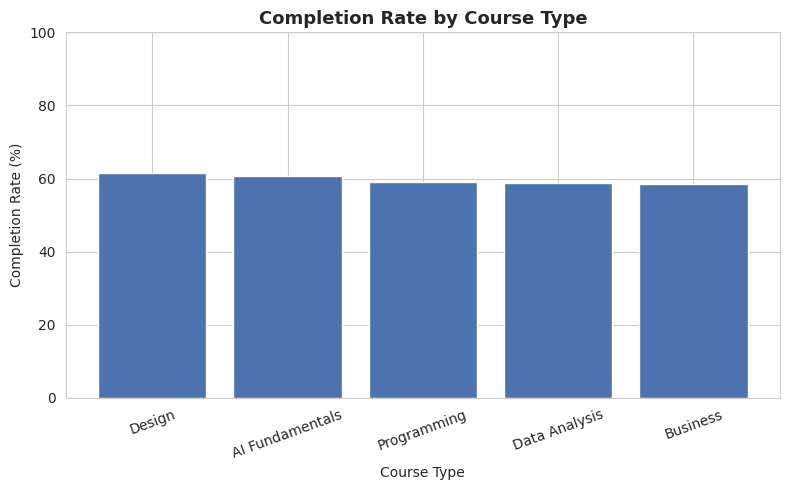

In [54]:
# task 3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


# Subtask 3.1: Course type completion visual

completion_by_course = (
    df.groupby('course_type')['completion_status']
    .apply(lambda s: (s == 'Completed').mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(completion_by_course.index, completion_by_course.values, color='#4C72B0')
ax.set_title('Completion Rate by Course Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Course Type')
ax.set_ylabel('Completion Rate (%)')
ax.set_ylim(0, 100)
plt.xticks(rotation=20)



plt.tight_layout()
plt.show()



This showes that design has the highest completion rate while business has the lowest but the differance are not significant

/tmp/ipykernel_1066/806640217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='learning_mode', y='engagement_score',


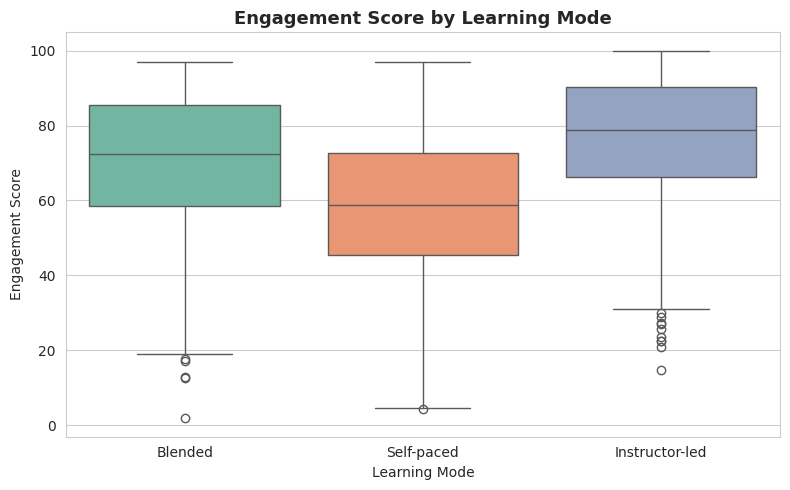

In [55]:
# Subtask 3.2: Learning mode engagement visual

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='learning_mode', y='engagement_score',
            palette='Set2', ax=ax)
ax.set_title('Engagement Score by Learning Mode', fontsize=13, fontweight='bold')
ax.set_xlabel('Learning Mode')
ax.set_ylabel('Engagement Score')
plt.tight_layout()
plt.show()

engagement_by_mode = df.groupby('learning_mode')['engagement_score'].median().sort_values(ascending=False)


This showes that Instructor-led shows the highest median engagement , while Self-paced shows the lowest and the differance is pretty obvious suggesting that learning mode has some association with how engaged learners are.

/tmp/ipykernel_1066/853425198.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='participation_level', y='final_score',


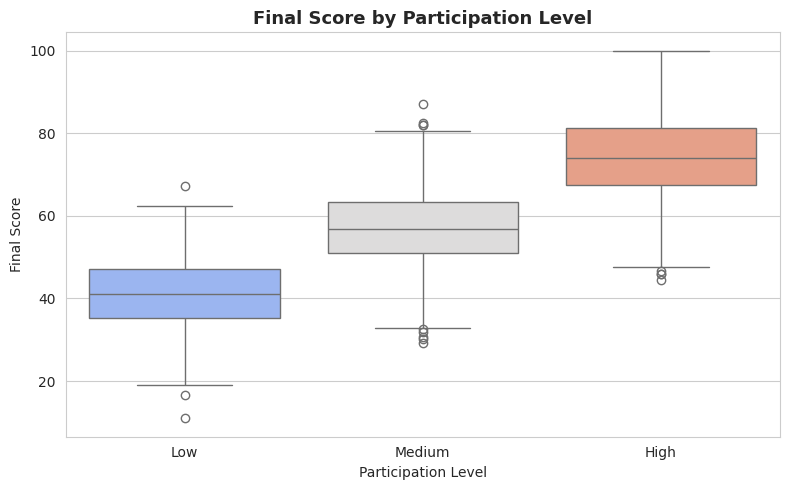

In [56]:


# Subtask 3.3: Participation and final score visual

participation_order = ['Low', 'Medium', 'High']  # preserve logical order

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='participation_level', y='final_score',
            order=participation_order, palette='coolwarm', ax=ax)
ax.set_title('Final Score by Participation Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Participation Level')
ax.set_ylabel('Final Score')
plt.tight_layout()
plt.show()



This showes that median final score is the lowest at a low participation level while its the highest at high participation level whice makes sense indicating that higher participation is assosiated with high final scores

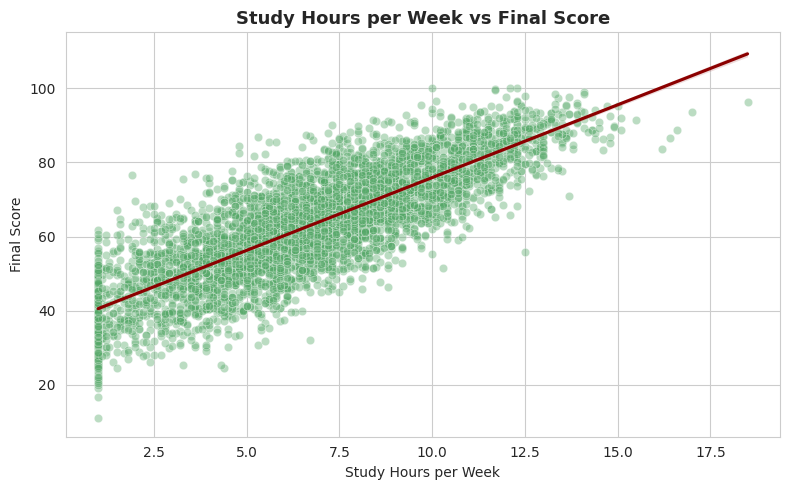

In [57]:


# Subtask 3.4: Study behavior relationship visual

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='study_hours_per_week', y='final_score',
                 alpha=0.4, color='#55A868', ax=ax)
sns.regplot(data=df, x='study_hours_per_week', y='final_score',
            scatter=False, color='darkred', ax=ax)
ax.set_title('Study Hours per Week vs Final Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Final Score')
plt.tight_layout()
plt.show()



This showes that there is a strong positive relationship between study hours and final score which means that more study time tends to align with higher scores but we cant say that simply studying more causes better scores.

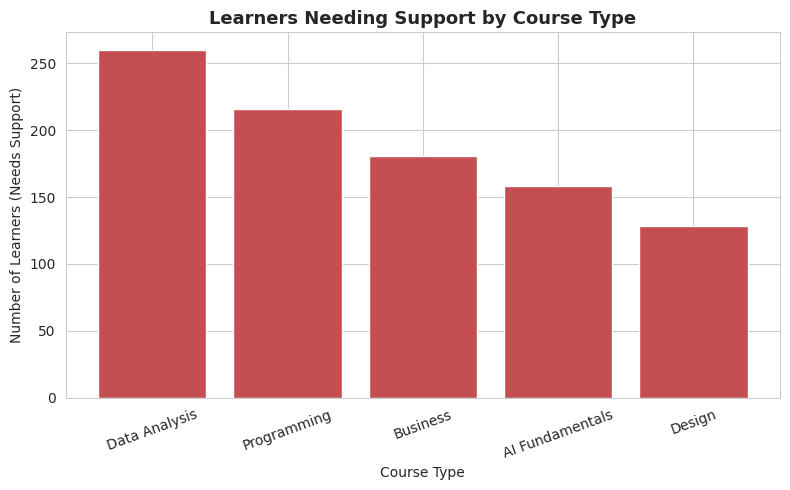

In [58]:
# Subtask 3.5: Learner support segment visual

# Define "needs support" using performance_category (already labeled in the data)
support_counts = (
    df.groupby(['course_type', 'performance_category'])
    .size()
    .unstack(fill_value=0)
)

# Focus on the "Needs Support" column, sorted to see which course types have the most
needs_support_by_course = support_counts['Needs Support'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(needs_support_by_course.index, needs_support_by_course.values, color='#C44E52')
ax.set_title('Learners Needing Support by Course Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Course Type')
ax.set_ylabel('Number of Learners (Needs Support)')
plt.xticks(rotation=20)



plt.tight_layout()
plt.show()



This showes that Data Analysis has the most learners flagged as 'Needs Support' making it a priority segment for targeted intervention while design is the least

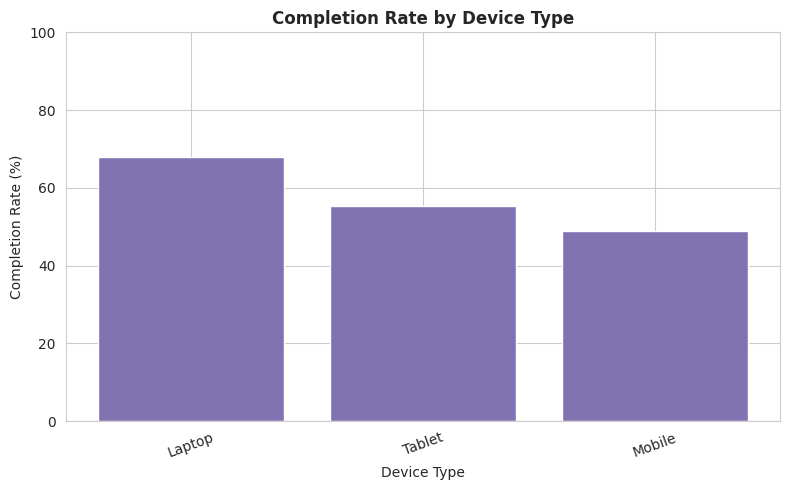

In [59]:
# Subtask 3.6: Device completion visual
completion_by_device = (
    df.groupby('device_type')['completion_status']
    .apply(lambda s: (s == 'Completed').mean() * 100)
    .sort_values(ascending=False)
)



fig, axes = plt.subplots(figsize=(8, 5))

axes.bar(completion_by_device.index, completion_by_device.values, color='#8172B2')
axes.set_title('Completion Rate by Device Type', fontsize=12, fontweight='bold')
axes.set_ylabel('Completion Rate (%)')
axes.set_xlabel('Device Type')
axes.set_ylim(0, 100)
plt.xticks(rotation=20)


plt.tight_layout()
plt.show()


This showes that laptop learners complete at the highest completion rate while mobile at the lowest

/tmp/ipykernel_1066/2378495080.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='participation_level', y='final_score',
/tmp/ipykernel_1066/2378495080.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='learning_mode', y='engagement_score', palette='Set2', ax=ax6)


Text(0, 0.5, 'Engagement Score')

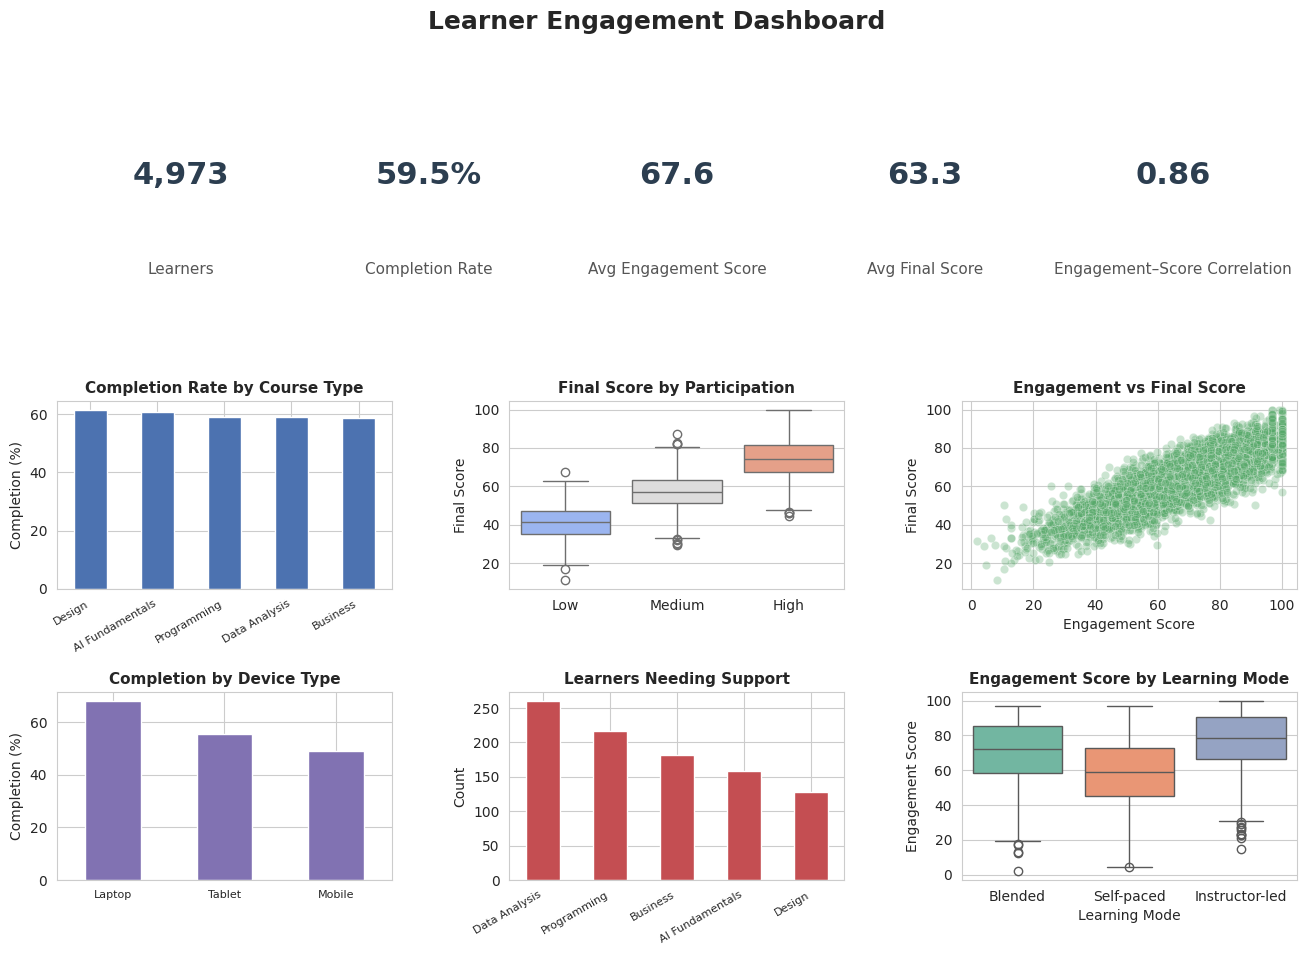

In [60]:



# task 4
# Subtask 4.1 + 4.2: Dashboard KPIs, visuals, and layout

# --- KPIs ---
learner_count = len(df)
completion_rate = (df['completion_status'] == 'Completed').mean() * 100
avg_engagement = df['engagement_score'].mean()
avg_final_score = df['final_score'].mean()
engagement_performance_corr = df['engagement_score'].corr(df['final_score'])

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

fig.suptitle('Learner Engagement Dashboard', fontsize=18, fontweight='bold', y=0.98)

# --- KPI row (top, spanning all 3 columns as 5 small stat cards) ---
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis('off')

kpis = [
    (f"{learner_count:,}", "Learners"),
    (f"{completion_rate:.1f}%", "Completion Rate"),
    (f"{avg_engagement:.1f}", "Avg Engagement Score"),
    (f"{avg_final_score:.1f}", "Avg Final Score"),
    (f"{engagement_performance_corr:.2f}", "Engagement–Score Correlation"),
]
n = len(kpis)
for i, (value, label) in enumerate(kpis):
    x = (i + 0.5) / n
    kpi_ax.text(x, 0.65, value, ha='center', va='center', fontsize=22, fontweight='bold', color='#2C3E50')
    kpi_ax.text(x, 0.15, label, ha='center', va='center', fontsize=11, color='#555555')
kpi_ax.set_xlim(0, 1)
kpi_ax.set_ylim(0, 1)


# --- Visual 1: Completion rate by course type ---
ax1 = fig.add_subplot(gs[1, 0])
completion_by_course.plot(kind='bar', ax=ax1, color='#4C72B0')
ax1.set_title('Completion Rate by Course Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Completion (%)')
ax1.set_xlabel('')
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# --- Visual 2: Final score by participation level ---
ax2 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x='participation_level', y='final_score',
            order=participation_order, palette='coolwarm', ax=ax2)
ax2.set_title('Final Score by Participation', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Final Score')

# --- Visual 3: Engagement vs Final Score relationship ---
ax3 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df, x='engagement_score', y='final_score', alpha=0.3, color='#55A868', ax=ax3)
ax3.set_title('Engagement vs Final Score', fontsize=11, fontweight='bold')
ax3.set_xlabel('Engagement Score')
ax3.set_ylabel('Final Score')

# --- Visual 4: Completion by device type
ax4 = fig.add_subplot(gs[2, 0])
completion_by_device.plot(kind='bar', ax=ax4, color='#8172B2')
ax4.set_title('Completion by Device Type', fontsize=11, fontweight='bold')
ax4.set_ylabel('Completion (%)')
ax4.set_xlabel('')
plt.setp(ax4.get_xticklabels(), rotation=0, fontsize=8)

# --- Visual 5: Needs Support by course type
ax5 = fig.add_subplot(gs[2, 1])
needs_support_by_course.plot(kind='bar', ax=ax5, color='#C44E52')
ax5.set_title('Learners Needing Support', fontsize=11, fontweight='bold')
ax5.set_ylabel('Count')
ax5.set_xlabel('')
plt.setp(ax5.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# --- Visual 6: Engagement by learning mode ---
ax6 = fig.add_subplot(gs[2, 2])
sns.boxplot(data=df, x='learning_mode', y='engagement_score', palette='Set2', ax=ax6)
ax6.set_title('Engagement Score by Learning Mode', fontsize=11, fontweight='bold')
ax6.set_xlabel('Learning Mode'); ax6.set_ylabel('Engagement Score')


This showes the importeant numbers and percentages and visuals i discussed earlier